In [24]:
import pandas as pd
training_data_df = pd.read_csv("training_data_202601.csv")
clocks_df = training_data_df[training_data_df["Painting"] == "The Persistence of Memory"]
starry_df = training_data_df[training_data_df["Painting"] == "The Starry Night"]
lilies_df = training_data_df[training_data_df["Painting"] == "The Water Lily Pond"]

paintings = ['clocks', 'starry', 'lilies']
dfs = [clocks_df, starry_df, lilies_df]

In [37]:
output_files = []
for painting in paintings:
    output_files.append(("Describe how this painting makes you feel.", f'text/{painting}_feel.txt'))
    output_files.append(("If this painting was a food, what would be?", f'text/{painting}_food.txt'))
    output_files.append(("Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.", f'text/{painting}_soundtrack.txt'))
try:
    # Validate column existence
    for column_name, output_file in output_files:
        if "clocks" in output_file:
            df = clocks_df
        elif "starry" in output_file:
            df = starry_df
        else:
            df = lilies_df
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' does not exist in DataFrame.")

        # Export column to text file (one value per line)
        df[column_name].to_csv(output_file, index=False, header=False)

except (IOError, OSError) as file_error:
    print(f"File error: {file_error}")
except ValueError as val_error:
    print(f"Value error: {val_error}")
except Exception as e:
    print(f"Unexpected error: {e}")

In [ ]:
from PIL import Image
import numpy as np

clocks_coloring = np.array(Image.open("images/clocks.png"))
starry_coloring = np.array(Image.open("images/starry.png"))
lilies_coloring = np.array(Image.open("images/lilies.png"))
colorings = [clocks_coloring, starry_coloring, lilies_coloring]

Generating word cloud for 'Describe how this painting makes you feel.' from 'clocks_feel.txt'...


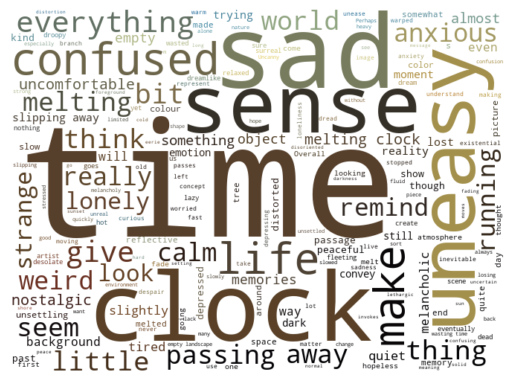

Generating word cloud for 'If this painting was a food, what would be?' from 'clocks_food.txt'...


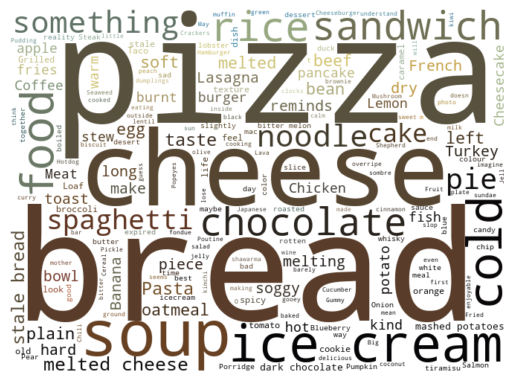

Generating word cloud for 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.' from 'clocks_soundtrack.txt'...


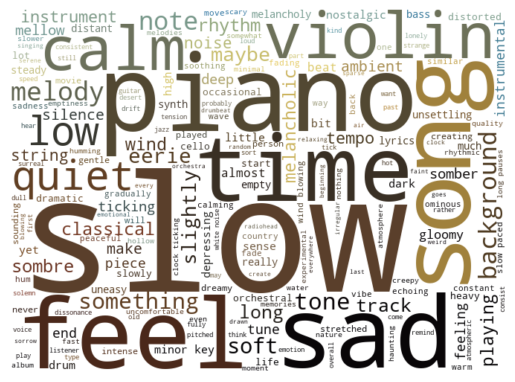

Generating word cloud for 'Describe how this painting makes you feel.' from 'starry_feel.txt'...


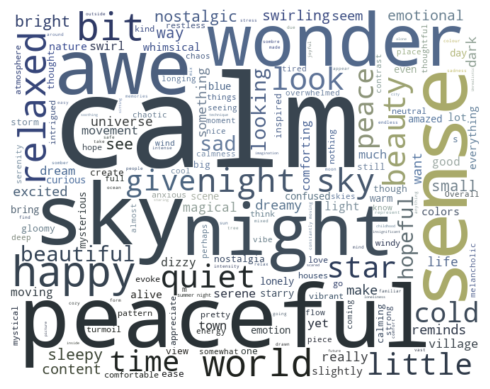

Generating word cloud for 'If this painting was a food, what would be?' from 'starry_food.txt'...


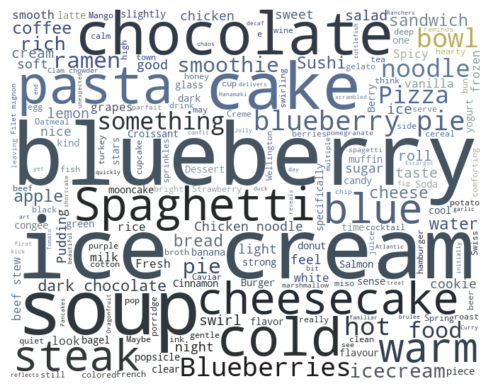

Generating word cloud for 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.' from 'starry_soundtrack.txt'...


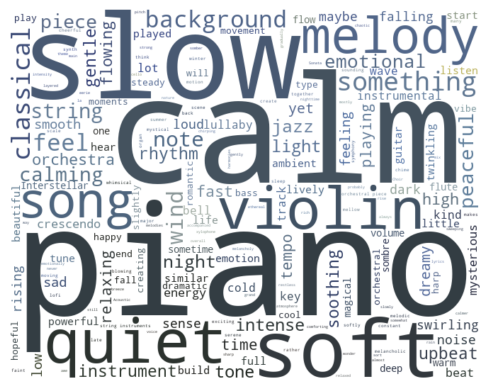

Generating word cloud for 'Describe how this painting makes you feel.' from 'lilies_feel.txt'...


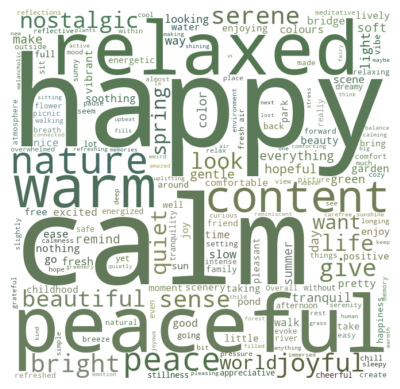

Generating word cloud for 'If this painting was a food, what would be?' from 'lilies_food.txt'...


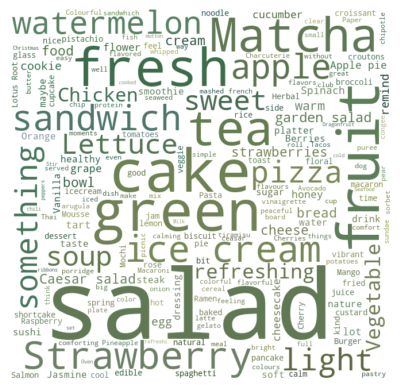

Generating word cloud for 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.' from 'lilies_soundtrack.txt'...


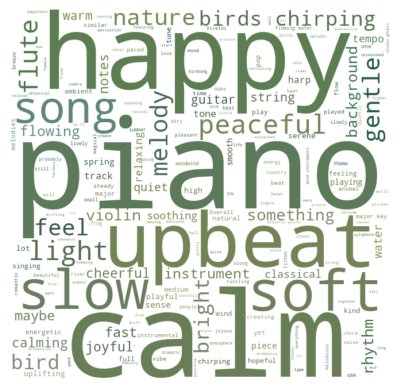

In [ ]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

for column_name, output_file in output_files:
    if "clocks" in output_file:
        coloring = clocks_coloring
    elif "starry" in output_file:
        coloring = starry_coloring
    else:
        coloring = lilies_coloring

    stopwords = set(WordCloud().stopwords)
    for word in column_name.strip('.,!?()[]{}"\'').split():
        stopwords.add(word)
    if "feel" in column_name:
        stopwords.add("feeling")
        stopwords.add("feelings")
        stopwords.add("feels")
        stopwords.add("felt")
    elif "food" in column_name:
        stopwords.add("foods")
    else:
        stopwords.add("sound")
        stopwords.add("sounds")
        stopwords.add("soundtracks")
        stopwords.add("music")
        
    with open(output_file, 'r') as file:
        text = file.read()
        wordcloud = WordCloud(stopwords=stopwords, mask=coloring, background_color='white').generate(text)

    image_colors = ImageColorGenerator(coloring)

    plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
    plt.axis("off")
    plt.show()